<a href="https://colab.research.google.com/github/cotymayer/constanza-mayer-ia-biomed/blob/main/Entrega4Parte2_Senales_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIG4B — Clase 12
## Práctica: ECG, EEG y PPG — lo esencial

Tarea acompañante de la **Clase 12** (señales 1D biomédicas). Los datos vienen hechos; los **modelos los implementan ustedes** siguiendo las especificaciones del PDF de la clase.

Ejercicios:

- **1.1** — usar `neurokit2` para estimar bpm en ECG sintético.
- **1.2** — implementar la **toy CNN** de slide 21 y entrenarla para clasificar arritmias.
- **2.1** — implementar **EEGNet** siguiendo slide 29 para clasificar carga cognitiva.
- **3.1** — implementar un **mini-Transformer 1D** y verificar que resuelve la tarea de contexto largo donde una CNN falla.

Autores: Paulo Veiga y Marco Sanchez Sorondo · Mayo 2026

## Setup

La primera celda instala lo que falte (necesario en Colab).

In [ ]:
import importlib, subprocess, sys
for pkg in ['wfdb', 'neurokit2']:
    try: importlib.import_module(pkg)
    except ImportError:
        print(f'instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('listo')

instalando wfdb...
instalando neurokit2...
listo


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import wfdb, neurokit2 as nk

np.random.seed(0); torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True
print(f'torch v{torch.__version__}  device={device}')

torch v2.11.0+cu128  device=cuda


## 1. ECG

**Idea central (slides 11, 14, 21):** un ECG es una secuencia de números + `fs`. La detección clásica de R-peaks es Pan-Tompkins; la versión AI usa CNNs. Para arritmias, una CNN simple ya supera lo que se podría hacer a mano con reglas R-R.

Cargamos un registro real de **MIT-BIH** (PhysioNet) y vemos cómo `neurokit2` lo procesa.

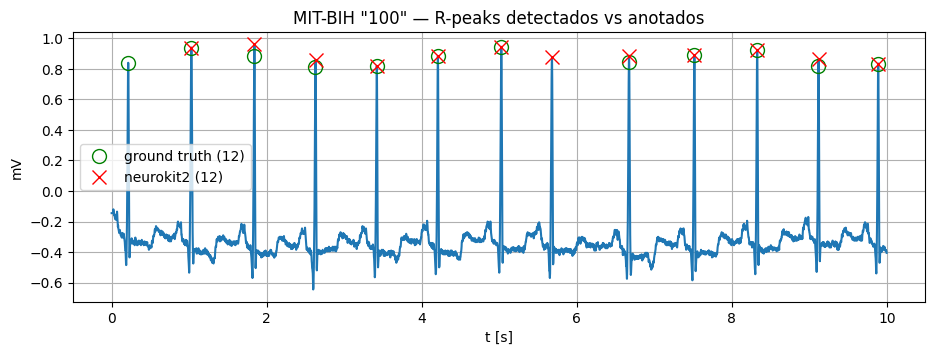

In [ ]:
FS_ECG = 360
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10*FS_ECG)
ecg_raw = record.p_signal[:, 0]
t_ecg = np.arange(len(ecg_raw)) / FS_ECG

ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=10*FS_ECG)
r_gt = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym == 'N'])

_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_ecg, ecg_raw)
plt.plot(t_ecg[r_gt], ecg_raw[r_gt], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_ecg[r_nk], ecg_raw[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('MIT-BIH "100" — R-peaks detectados vs anotados')
plt.show()

### Helper · generador de ECG sintético

Función provista para los ejercicios. **No es parte del ejercicio**, solo úsenla.

In [ ]:
def synthetic_ecg(duration_s, fs, hr_bpm):
    """ECG sintético: suma de gaussianas P-Q-R-S-T repetidas a hr_bpm."""
    t = np.arange(0, duration_s, 1/fs); rr = 60.0/hr_bpm
    ecg = np.zeros_like(t)
    waves = [(0.00,0.025,0.15),(0.15,0.010,-0.10),(0.17,0.008,1.20),(0.19,0.010,-0.25),(0.35,0.04,0.35)]
    for k in range(int(duration_s/rr)+1):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += amp * np.exp(-((t-t0-off)**2)/(2*sigma**2))
    return t, ecg

### Ejercicio 1.1 — estimar bpm con `neurokit2`

1. Generá un ECG sintético de 30 s con frecuencia cardíaca aleatoria entre 50 y 110 bpm (sin imprimir cuál).
2. Usá `nk.ecg_peaks` para detectar los R-peaks.
3. Estimá la frecuencia cardíaca a partir de los intervalos R-R y comparala con el valor real.

HR real:      82.9 bpm
HR estimada:  82.9 bpm


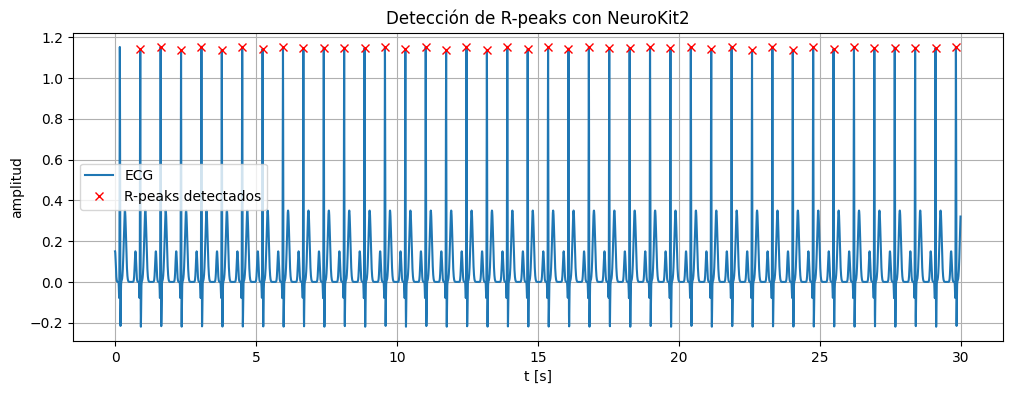

In [ ]:
# Tu código acá
fs = 360
hr_real = np.random.uniform(50, 110)

t, ecg = synthetic_ecg(duration_s=30, fs=fs, hr_bpm=hr_real)

# detección de R-peaks
_, info = nk.ecg_peaks(ecg, sampling_rate=fs)
r_peaks = info['ECG_R_Peaks']

# intervalos RR
rr_intervals = np.diff(r_peaks) / fs

# estimación de HR
hr_estimada = 60 / np.mean(rr_intervals)

print(f'HR real:      {hr_real:.1f} bpm')
print(f'HR estimada:  {hr_estimada:.1f} bpm')

plt.figure(figsize=(12,4))
plt.plot(t, ecg, label='ECG')
plt.plot(t[r_peaks], ecg[r_peaks],'rx', label='R-peaks detectados')

plt.xlabel('t [s]')
plt.ylabel('amplitud')
plt.title('Detección de R-peaks con NeuroKit2')
plt.legend()

plt.show()

### Dataset de arritmias (provisto)

Tres clases (slide 13): **normal** (RR regular), **AFIB** (RR aleatorio + morfología sucia), **bigeminismo** (RR alternante corto-largo). El dataset y el split train/val vienen hechos; ustedes se ocupan del modelo.

Train: (720, 500)  Val: (180, 500)  Clases: ['normal', 'AFIB', 'bigeminismo']


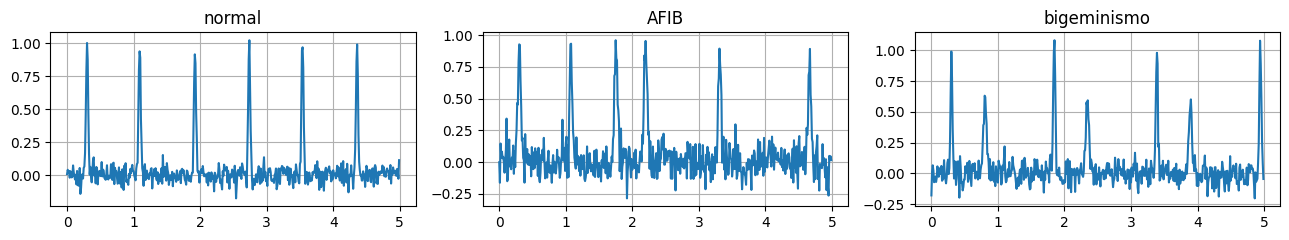

In [ ]:
FS = 100; WIN = 500  # 5 s a 100 Hz

def make_rr_window(label, rng):
    t = np.arange(WIN) / FS
    sig = np.zeros(WIN, dtype=np.float32)
    if label == 0:
        hr = rng.uniform(60, 80)
        rrs = np.full(15, 60/hr) + rng.normal(0, 0.02, 15)
        amps, widths, noise = np.full(15, 1.0), np.full(15, 0.015), 0.05
    elif label == 1:
        rrs = rng.uniform(0.4, 1.4, 15)
        amps = np.full(15, 0.9) + rng.normal(0, 0.10, 15)
        widths = rng.uniform(0.018, 0.025, 15); noise = 0.10
    else:
        s = rng.uniform(0.45, 0.55); l = rng.uniform(1.05, 1.20)
        rrs = np.array([s, l] * 8)[:15] + rng.normal(0, 0.02, 15)
        amps = np.array([1.0, 0.6] * 8)[:15]
        widths = np.array([0.015, 0.025] * 8)[:15]; noise = 0.07
    t_pos = 0.3
    for rr, amp, w in zip(rrs, amps, widths):
        if t_pos >= WIN / FS: break
        sig += amp * np.exp(-((t - t_pos) ** 2) / (2 * w ** 2))
        t_pos += rr
    return sig + noise * rng.standard_normal(WIN).astype(np.float32)

rng = np.random.default_rng(0); n_per = 300
labels_arr = ['normal', 'AFIB', 'bigeminismo']
X = np.stack([make_rr_window(c, rng) for c in [0]*n_per + [1]*n_per + [2]*n_per])
y = np.array([0]*n_per + [1]*n_per + [2]*n_per, dtype=np.int64)
idx = rng.permutation(len(X)); X, y = X[idx], y[idx]
split = int(0.8*len(X))
X_tr, X_va, y_tr, y_va = X[:split], X[split:], y[:split], y[split:]
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Clases: {labels_arr}')

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, c in zip(axes, [0, 1, 2]):
    ax.plot(np.arange(WIN)/FS, X[y == c][0])
    ax.set_title(labels_arr[c])
plt.tight_layout(); plt.show()

### Ejercicio 1.2 — implementar y entrenar la toy CNN (slide 21)

Implementá **exactamente** la arquitectura de la slide 21 y entrenala sobre el dataset de arritmias.

**Arquitectura:**
```
Conv1D(in=1, out=16, kernel_size=5)  →  ReLU  →  MaxPool1D(kernel=2)
Conv1D(in=16, out=32, kernel_size=5) →  ReLU
GlobalAvgPool1D  →  Flatten  →  Linear(32, 3)
```

**Entrenamiento:** 15 epochs, optimizer Adam (lr=1e-3), loss `CrossEntropyLoss`, batch size 32.

**Reportar:**
- `val_acc` final
- matriz de confusión 3×3
- **sensibilidad** (recall) y **especificidad** por clase (las dos métricas clínicas clave)

*Pista para GlobalAvgPool1D:* en PyTorch se logra con `nn.AdaptiveAvgPool1d(1)` seguido de `nn.Flatten()`.

Epoch 1 - loss: 1.1079
Epoch 2 - loss: 1.0964
Epoch 3 - loss: 1.0856
Epoch 4 - loss: 1.0834
Epoch 5 - loss: 1.0808
Epoch 6 - loss: 1.0678
Epoch 7 - loss: 1.0647
Epoch 8 - loss: 0.9969
Epoch 9 - loss: 0.9800
Epoch 10 - loss: 0.9096
Epoch 11 - loss: 0.9709
Epoch 12 - loss: 0.8111
Epoch 13 - loss: 0.7571
Epoch 14 - loss: 0.6167
Epoch 15 - loss: 0.5600
Val accuracy: 0.972
[[51  0  0]
 [ 0 66  0]
 [ 5  0 58]]


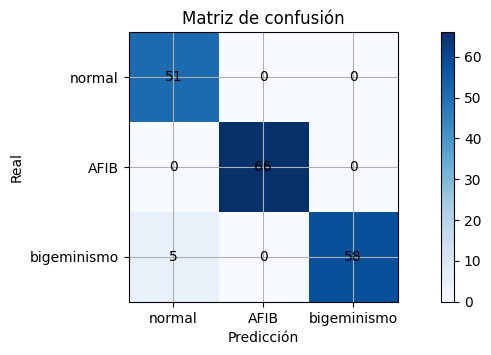

normal - sensibilidad: 1.000
AFIB - sensibilidad: 1.000
bigeminismo - sensibilidad: 0.921
normal - especificidad: 0.961
AFIB - especificidad: 1.000
bigeminismo - especificidad: 1.000


In [ ]:
# Tu código acá
from sklearn.metrics import confusion_matrix, recall_score

Xtr = torch.tensor(X_tr).float().unsqueeze(1)
Xva = torch.tensor(X_va).float().unsqueeze(1)

ytr = torch.tensor(y_tr).long()
yva = torch.tensor(y_va).long()

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=32)

class ToyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(16, 32, kernel_size=5),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = ToyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1} - loss: {loss.item():.4f}')

model.eval()
preds = []
targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        out = model(xb)
        pred = out.argmax(dim=1).cpu().numpy()
        preds.extend(pred)
        targets.extend(yb.numpy())
#accuracy
acc = np.mean(np.array(preds) == np.array(targets))
print(f'Val accuracy: {acc:.3f}')

#matriz de confusión
cm = confusion_matrix(targets, preds)
print(cm)

plt.imshow(cm, cmap='Blues')
plt.xticks([0,1,2], labels_arr)
plt.yticks([0,1,2], labels_arr)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='black'
        )
plt.colorbar()
plt.show()

#sensibilidad
recall = recall_score(targets, preds, average=None)

for i, r in enumerate(recall):
    print(f'{labels_arr[i]} - sensibilidad: {r:.3f}')

#especificidad
for i in range(3):
    tp = cm[i,i]
    fn = cm[i,:].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    spec = tn / (tn + fp)
    print(f'{labels_arr[i]} - especificidad: {spec:.3f}')

### Preguntas conceptuales — toy CNN (Ej 1.2)

Justificá brevemente cada decisión de la arquitectura y del entrenamiento. Una o dos oraciones por pregunta.

1. ¿Por qué usamos `Conv1D` en vez de `Linear` para procesar la señal?
2. `kernel_size=5` a `fs=100 Hz`: ¿cuántos milisegundos cubre el kernel? ¿Por qué ese tamaño tiene sentido para un ECG?
3. ¿Para qué sirve `MaxPool1d(2)`?
4. ¿Por qué la segunda Conv1D pasa de 16 a 32 filtros (el número crece al profundizar)?
5. ¿Qué hace `AdaptiveAvgPool1d(1)`? ¿Qué se gana y qué se pierde al colapsar toda la dimensión temporal?
6. ¿Por qué la última capa `Linear` tiene **3** outputs y no hay activación softmax después?
7. ¿Por qué `CrossEntropyLoss` es la loss apropiada y por qué usamos `Adam` y no `SGD`?

*Respuestas:*
1. El ECG tiene patrones locales en el tiempo, como los picos QRS, y Conv1D puede detectarlos recorriendo la señal, mientras que una capa Linear no aprovecha esa estructura temporal.
2. Cada muestra dura 10 ms (1/100 = 0.01s), entonces un kernerl de 5 muestras son 50 ms. Ese tamaño tiene sentido porque los complejos QRS duran aproximadamente ese orden de tiempo
3. Sirve para reducir el tamaño temporal de la señal y se queda con la información más importante. Esto disminuye el costo computacional y hace más robusta la red.
4. Porque en capas más profundas la red aprende patrones más complejos. Aumentando el número de filtros tiene mayor capacidad para representar distintas morfologías y relaciones temporales del ECG.
5. Promedia cada feature a lo largo del tiempo, dejando un único valor. Se gana una representación compacta para clasificar y menos parametros, pero se pierde información exacta de cuándo ocurren los eventos en la señal.
6. Porque hay 3 clases posibles: normal, AFIB y bigeminismo. No se agrega softmax porque CrossEntropyLoss ya lo aplica internamente.
7. CrossEntropyLoss es la estándar para clasificación multiclase. Adam se usa porque suele entrenar más rápido y de forma más estable que SGD.

## 2. EEG

**Idea central (slides 25, 27, 29):** EEG es una **matriz** `[canales × tiempo]`, no un vector. **EEGNet** (Lawhern 2018) es el baseline estándar. Lo implementamos siguiendo la slide 29 del PDF.

Dataset sintético con bandas EEG realistas: carga cognitiva **baja** (predominio α) vs **alta** (predominio β).

In [ ]:
FS_EEG = 128; N_CHANS = 14; N_SAMPLES = 128  # 1 segundo
BANDS = {'delta':(0.5,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(13,30)}

def make_eeg_epoch(label, rng):
    if label == 0:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':1.5, 'beta':0.3}
    else:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':0.3, 'beta':1.5}
    t = np.arange(N_SAMPLES) / FS_EEG
    eeg = np.zeros((N_CHANS, N_SAMPLES), dtype=np.float32)
    for c in range(N_CHANS):
        for band, amp in amps.items():
            lo, hi = BANDS[band]
            eeg[c] += amp * np.sin(2*np.pi*rng.uniform(lo, hi)*t + rng.uniform(0, 2*np.pi))
        eeg[c] += 0.2 * rng.standard_normal(N_SAMPLES)
    return eeg

rng = np.random.default_rng(5); n_per = 300
X_eeg = np.stack([make_eeg_epoch(c, rng) for c in [0]*n_per + [1]*n_per])
y_eeg = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_eeg)); X_eeg, y_eeg = X_eeg[idx], y_eeg[idx]
split = int(0.8*len(X_eeg))
X_tr_e, X_va_e = X_eeg[:split], X_eeg[split:]
y_tr_e, y_va_e = y_eeg[:split], y_eeg[split:]
print('Train:', X_tr_e.shape, 'Val:', X_va_e.shape)

Train: (480, 14, 128) Val: (120, 14, 128)


### Ejercicio 2.1 — implementar y entrenar EEGNet (slide 29)

Implementá EEGNet siguiendo la slide 29 del PDF y entrenala para clasificar carga cognitiva (baja vs alta).

**Arquitectura (slide 29):**

```
Input [batch, 1, C=14, T=128]

BLOQUE 1 — temporal conv
  Conv2D(in=1, out=F1=8, kernel=(1, 64), padding=(0, 32), bias=False)
  BatchNorm2d(F1)

BLOQUE 2 — depthwise spatial conv (combina canales)
  Conv2D(in=F1, out=F1*D=16, kernel=(C=14, 1), groups=F1, bias=False)
  BatchNorm2d(F1*D)  →  ELU  →  AvgPool2D(kernel=(1, 4))  →  Dropout(0.25)

BLOQUE 3 — separable conv
  Conv2D depthwise: kernel=(1, 16), groups=F1*D, padding=(0, 8), bias=False
  Conv2D pointwise: kernel=(1, 1), out=F2=16, bias=False
  BatchNorm2d(F2)  →  ELU  →  AvgPool2D(kernel=(1, 8))  →  Dropout(0.25)

HEAD
  Flatten  →  Linear(→ 2 clases)
```

**Entrenamiento:** 10 epochs, Adam (lr=1e-3), `CrossEntropyLoss`, batch size 32.

**Tip:** el tensor entra como `[B, C, T]`. Tenés que agregarle la dimensión de canal con `x.unsqueeze(1)` antes del primer Conv2D para que quede `[B, 1, C, T]`.

Epoch 1 - loss: 0.6062
Epoch 2 - loss: 0.4454
Epoch 3 - loss: 0.3019
Epoch 4 - loss: 0.0770
Epoch 5 - loss: 0.0410
Epoch 6 - loss: 0.0255
Epoch 7 - loss: 0.0062
Epoch 8 - loss: 0.0115
Epoch 9 - loss: 0.0061
Epoch 10 - loss: 0.0137
Val accuracy: 1.000
[[68  0]
 [ 0 52]]


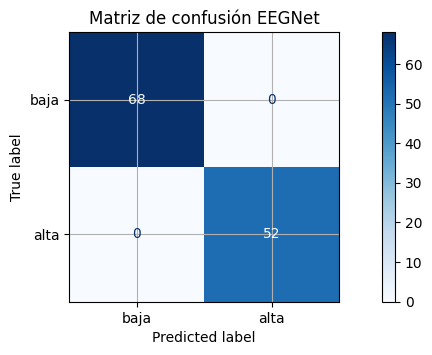

In [ ]:
# Tu código acá
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Xtr = torch.tensor(X_tr_e).float()
Xva = torch.tensor(X_va_e).float()

ytr = torch.tensor(y_tr_e).long()
yva = torch.tensor(y_va_e).long()

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=32)

class EEGNet(nn.Module):
    def __init__(self):
        super().__init__()
        F1 = 8
        D = 2
        F2 = 16

        self.net = nn.Sequential(
            #bloque 1
            nn.Conv2d(in_channels=1, out_channels=F1, kernel_size=(1,64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1),

            #bloque 2
            nn.Conv2d(in_channels=F1, out_channels=F1*D, kernel_size=(14,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,4)),
            nn.Dropout(0.25),

            #bloque 3
            nn.Conv2d(in_channels=F1*D, out_channels=F1*D, kernel_size=(1,16), padding=(0,8), groups=F1*D, bias=False),
            nn.Conv2d(in_channels=F1*D, out_channels=F2, kernel_size=(1,1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(0.25),

            nn.Flatten()
        )

        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        # [B,C,T] → [B,1,C,T]
        x = x.unsqueeze(1)
        x = self.net(x)
        return self.classifier(x)

#entrenamiento
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = EEGNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1} - loss: {loss.item():.4f}')

#evaluación
model.eval()
preds = []
targets = []

with torch.no_grad():
    for xb, yb in val_loader:
      xb = xb.to(device)
      out = model(xb)
      pred = out.argmax(dim=1).cpu().numpy()
      preds.extend(pred)
      targets.extend(yb.numpy())

#accuracy
acc = np.mean(np.array(preds) == np.array(targets))
print(f'Val accuracy: {acc:.3f}')

#matriz de confusión
cm = confusion_matrix(targets, preds)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['baja','alta'])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión EEGNet')
plt.show()

### Preguntas conceptuales — EEGNet (Ej 2.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el **depth multiplier** `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una **separable convolution** (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

*Respuestas:*
1. Usamos un kernel (1,64) para analizar patrones temporales dentro de cada canal sin mezclar la información espacial entre electrodos. Primero la red aprende ritmos EEG y después combina canales.
2. A fs = 128 Hz, un kernel de 64 cubre 0.5 s. Ese tamaño tiene sentido porque las ondas EEG son más lentas comparadas con ECG y hace falta observar varios ciclos para distinguir bandas alpha o beta.
3. La conv (14,1) combina información de todos los canales y aprende relaciones espaciales entre electrodos. Es depthwise porque cada filtro temporal se procesa por separado.
4. El depth multiplier D=2 significa que por cada filtro temporal inicial la red aprende dos combinaciones espaciales distintas.
5. Se usa AvgPool porque importa más la actividad promedio que picos aislados. En EEG las señales oscilan pasitivas y negativas constantemente por lo que se usa ELU que, a diferencia de ReLU, conserva la información negativa y entrena más estable.
6. Una separable convolution divide el procesamiento en dos, primero procesa cada canal por separado (depthwise) y después mezcla la información (pointwise). Se usa porque reduce mucho la cantidad de parámetros respecto a una convolución estándar.
7. El pool del bloque 3 es más grande porque en capas profundas ya no hace falta conservar tanto detalle temporal. La red ya aprendió features más abstractas y puede comprimir más la señal.
8. Dropout(0.25) apaga neuronas aleatoriamente durante el entrenamiento para evitar overfitting y hacer que el modelo generalice mejor.

## 3. CNN ↔ Transformer — campo receptivo y atención (slides 31–33)

**Lo que el PDF quiere mostrar:** una CNN tiene **campo receptivo finito** (slide 31). Un Transformer mira **toda la secuencia** de una sola pasada (slide 32) usando **self-attention** (slide 33).

Tarea: ventanas de 30 s con dos *spike trains* — uno al segundo 1, otro al segundo 25 — cada uno a 5 Hz o 12 Hz. Preguntamos si matchean. Para responder hay que comparar dos eventos separados **24 segundos** — fuera del campo receptivo de una CNN razonable.

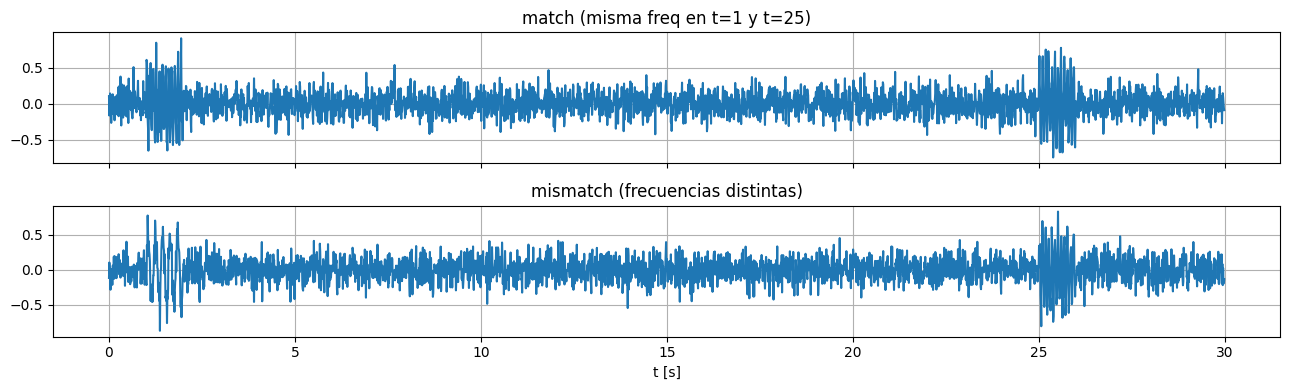

In [ ]:
FS_LC = 100; DUR_LC = 30.0; T_LC = int(DUR_LC * FS_LC)

def make_long_context(label, rng):
    t = np.arange(T_LC) / FS_LC
    sig = 0.15 * rng.standard_normal(T_LC).astype(np.float32)
    f1 = rng.choice([5, 12])
    sig[(t >= 1) & (t < 2)] += 0.5 * np.sin(2*np.pi*f1*t[(t >= 1) & (t < 2)])
    f2 = f1 if label == 0 else (12 if f1 == 5 else 5)
    sig[(t >= 25) & (t < 26)] += 0.5 * np.sin(2*np.pi*f2*t[(t >= 25) & (t < 26)])
    return sig.astype(np.float32)

rng = np.random.default_rng(11); n_per = 400
X_lc = np.stack([make_long_context(c, rng) for c in [0]*n_per + [1]*n_per])
y_lc = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_lc)); X_lc, y_lc = X_lc[idx], y_lc[idx]
split = int(0.8*len(X_lc))
X_tr_lc, X_va_lc = X_lc[:split], X_lc[split:]
y_tr_lc, y_va_lc = y_lc[:split], y_lc[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
axes[0].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 0][0]); axes[0].set_title('match (misma freq en t=1 y t=25)')
axes[1].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 1][0]); axes[1].set_title('mismatch (frecuencias distintas)')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Demo · una CNN no puede resolver esta tarea

Definimos una CNN razonable (3 conv layers con stride=2) y la entrenamos. Su campo receptivo no llega a abarcar los 30 s — queda en *chance level*.

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr)),
                        batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = crit(model(xb.to(device).unsqueeze(1)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_va).float().to(device).unsqueeze(1)).argmax(1).cpu().numpy()
    return (pred == y_va).mean()

torch.manual_seed(0)
acc_cnn = train_clf(SmallCNN().to(device), X_tr_lc, y_tr_lc, X_va_lc, y_va_lc)
print(f'SmallCNN val_acc = {acc_cnn:.3f}  (chance = 0.50, CNN limitada por campo receptivo)')

SmallCNN val_acc = 0.525  (chance = 0.50, CNN limitada por campo receptivo)


### Ejercicio 3.1 — implementar y entrenar un mini-Transformer 1D (slide 33)

Implementá un Transformer simple que pueda resolver la tarea. La ventaja sobre la CNN es que **self-attention conecta cualquier par de instantes en una sola capa** — sin importar la distancia.

**Arquitectura:**

```
1. Patch embedding
   Conv1D(in=1, out=64, kernel_size=50, stride=50)   # cada patch = 0.5 s
   transpose para quedar [B, N_patches=60, dim=64]

2. Positional embedding (parámetro aprendido)
   nn.Parameter de shape [1, N_patches=60, dim=64], inicializado random pequeño
   Se suma a la salida del patch embedding

3. Bloque de atención (con conexión residual)
   LayerNorm  →  MultiheadAttention(dim=64, num_heads=4, batch_first=True)
   suma residual con la entrada del bloque

4. Bloque feed-forward (con conexión residual)
   LayerNorm  →  Linear(64 → 128)  →  GELU  →  Linear(128 → 64)
   suma residual

5. Clasificador
   promedio sobre patches (mean dim=1)  →  Linear(64 → 2)
```

**Entrenamiento:** 10 epochs, Adam (lr=3e-4), `CrossEntropyLoss`.

Después de entrenar, comparé el `val_acc` con `acc_cnn`. El Transformer debería resolver la tarea (~1.0), mientras que la CNN se queda en chance.

In [ ]:
# Tu código acá
Xtr = torch.tensor(X_tr_lc).float()
Xva = torch.tensor(X_va_lc).float()

ytr = torch.tensor(y_tr_lc).long()
yva = torch.tensor(y_va_lc).long()

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=32)

class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        #patch embedding
        self.patch_embed = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=50, stride=50)
        n_patches = 60

        #positional embedding
        self.pos_embed = nn.Parameter(0.02 * torch.randn(1, n_patches, 64))

        #bloque de atención
        self.norm1 = nn.LayerNorm(64)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)

        #feed-forward
        self.norm2 = nn.LayerNorm(64)
        self.ffn = nn.Sequential(
            nn.Linear(64, 128),
            nn.GELU(),
            nn.Linear(128, 64)
        )

        #clasificador
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.patch_embed(x)
        x = x.transpose(1, 2)
        x = x + self.pos_embed
        y = self.norm1(x)
        attn_out, _ = self.attn(y, y, y)
        x = x + attn_out
        y = self.norm2(x)
        x = x + self.ffn(y)

        #promedio sobre patches
        x = x.mean(dim=1)

        #clasificación
        return self.classifier(x)

#entrenamiento
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MiniTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1} - loss: {loss.item():.4f}')

#evaluación
model.eval()
preds = []
targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        out = model(xb)
        pred = out.argmax(dim=1).cpu().numpy()
        preds.extend(pred)
        targets.extend(yb.numpy())

acc_transformer = np.mean(
    np.array(preds) == np.array(targets)
)

print(f'Transformer val_acc = {acc_transformer:.3f}')
print(f'SmallCNN val_acc    = {acc_cnn:.3f}')

Epoch 1 - loss: 0.6918
Epoch 2 - loss: 0.6879
Epoch 3 - loss: 0.6480
Epoch 4 - loss: 0.5368
Epoch 5 - loss: 0.3050
Epoch 6 - loss: 0.0087
Epoch 7 - loss: 0.0014
Epoch 8 - loss: 0.0009
Epoch 9 - loss: 0.0007
Epoch 10 - loss: 0.0006
Transformer val_acc = 1.000
SmallCNN val_acc    = 0.525


### Preguntas conceptuales — mini-Transformer (Ej 3.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. El **patch embedding** es una `Conv1D(kernel=50, stride=50)`. ¿Para qué partir la señal en patches? ¿Qué pasaría si pusiéramos todo el tensor directamente en la atención?
2. ¿Cuántos segundos cubre cada patch (a `fs=100 Hz`) y cuántos patches totales hay en una ventana de 30 s?
3. ¿Para qué hace falta el **positional embedding**? ¿Qué pasaría sin él en una tarea como esta (match/mismatch)?
4. En `MultiheadAttention(dim=64, num_heads=4)`: ¿qué representa cada **cabeza** y por qué se usan varias en paralelo?
5. ¿Por qué hay **conexiones residuales** (`e = e + attn_out`)? ¿Qué problema previenen?
6. ¿Para qué sirve el **bloque feed-forward** después de la atención si ya hicimos atención? ¿Por qué la dimensión interna es `2 × EMBED`?
7. ¿Por qué `LayerNorm` y no `BatchNorm` (como sí usamos en EEGNet)?
8. ¿Por qué hacemos `e.mean(dim=1)` al final antes del clasificador?

*Respuestas:*
1. Se divide la señal en patches para reducir la cantidad de elementos que procesa la atenció. Si usáramos las 3000 muestras directamente, sería menos eficiente y el costo computacional sería mucho mayor.
2. Cada patch cubre 0.5 s de señal porque contiene 50 muestras a 100 Hz. En una ventana de 30 s se obtienen 60 patches.
3. El positional embedding le indica al Transformer la posición temporal de cada patch. Sin esta información perdería el orden de la secuencia y le costaría distinguir eventos que ocurren en distintos momentos.
4. Cada cabeza aprende relaciones diferentes entre los patches de la señal. Usar varias cabezas en paralelo permite capturar distintos tipos de información al mismo tiempo.
5. Las conexiones residuales conservan la información original y facilitan el entrenamiento. Ayudan a evitar problemas de gradientes y pérdida de información entre capas.
6. La atención relaciona los patches entre sí, mientras que el bloque feed-forward procesa y transforma la información obtenida. La dimensión interna mayor (128) aumenta la capacidad de representación del modelo antes de volver a 64.
7. LayerNorm normaliza cada muestra de forma independiente, sin depender del resto del batch. Es mas estable en Transformers, donde la atención mezcla información de distintas posiciones de la secuencia.
8. Se promedia sobre los patches para obtener una representación global de la señal completa. Esto reduce la secuencia a un único vector que puede utilizarse para la clasificación final.

## Cierre — takeaways de la clase

1. **Una señal 1D = lista de números + `fs`.** ECG, EEG y PPG son instancias del mismo concepto.
2. **El filtro deslizante es el throughline.** Pan-Tompkins → Conv1D → self-attention — lo que cambia es **cuántos parámetros**    y **cuánto contexto** ve cada operación.
3. **AI extiende al clásico, no lo reemplaza.** Pan-Tompkins de 1985 sigue siendo baseline en producción.
4. **Dimensionalidad escala el problema.** ECG (1D) → PPG (1D + movimiento) → EEG (2D = canales × tiempo). El framework es el mismo;    la arquitectura se adapta.
5. **Las CNNs tienen campo receptivo finito.** Cuando la tarea requiere contexto largo, hay que ir a Transformers.